Import libraries

In [1]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import os

Plot style



In [2]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 14

Functions

In [3]:
EPS = 1e-9  # Small epsilon for numerical stability
torch.set_default_dtype(torch.float32)


def strain_kinematics(t, gamma0, omega):
    return gamma0 * np.sin(omega * t)

def strain_rate_kinematics(t, gamma0, omega):
    return gamma0 * omega * np.cos(omega * t)

def saramito_exp_decay_plateau_ode_rhs_scaled(
    tau_current, gamma_s_current, gamma_dot_s_current,
    # Parameters are passed individually after unpacking
    G0, Ginf, γc,
    η0, ηinf, γdotc,
    ηp, τ0
    ):
    if not isinstance(tau_current, torch.Tensor):
        tau_current = torch.tensor(tau_current, dtype=torch.float32)

    abs_gamma_s_eff = torch.abs(gamma_s_current)
    eff_Gs_current = Ginf + (G0 - Ginf) * torch.exp(-abs_gamma_s_eff / (torch.relu(γc) + EPS))
    eff_lambda_current = ηp / (torch.relu(eff_Gs_current) + EPS)
    abs_tau = torch.abs(tau_current)
    max_term_s_val = torch.where(abs_tau > τ0,
                                 (abs_tau - τ0) / (abs_tau + EPS),
                                 torch.tensor(0.0, dtype=torch.float32, device=tau_current.device))
    dtau_vp_dt_s = (ηp * gamma_dot_s_current - max_term_s_val * tau_current) / (torch.relu(eff_lambda_current) + EPS)
    return dtau_vp_dt_s

Stage 1: Fitting to Kelvin-Voigt

--- STAGE 1: Fitting Kelvin-Voigt to Low-Strain Data ---
Successfully loaded Stage 1 data: 40att1.xlsx
Stage 1 Fitted SCALED G0s (relative to Stage 1 data): 0.9920
Stage 1 Fitted SCALED eta0s_solvent (relative to Stage 1 data): 0.1662
Stage 1 Derived PHYSICAL G0: 9664.8164 Pa
Stage 1 Derived PHYSICAL eta0_solvent: 160.3752 Pa.s


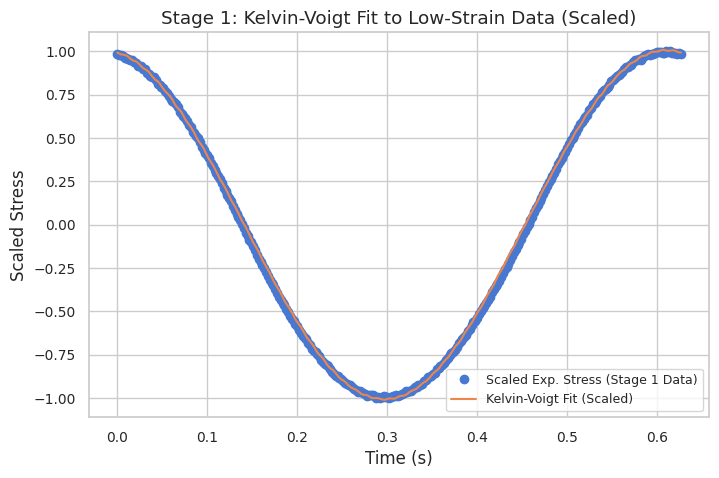

--------------------------------------------------------


In [4]:
print("--- STAGE 1: Fitting Kelvin-Voigt to Low-Strain Data ---")
XLSX_FILE_PATH_STAGE1 = '40att1.xlsx'
STRAIN_COLUMN_NAME = 'Strain'
STRESS_COLUMN_NAME = 'Stress'
omega_stage1 = 10.0

G0_physical_from_stage1 = None
eta0_solvent_physical_from_stage1 = None

try:
    df_stage1 = pd.read_excel(XLSX_FILE_PATH_STAGE1)
    print(f"Successfully loaded Stage 1 data: {XLSX_FILE_PATH_STAGE1}")
    strain_stage1_phys_np = df_stage1[STRAIN_COLUMN_NAME].values
    stress_stage1_phys_np = df_stage1[STRESS_COLUMN_NAME].values

    t_stage1_phys_np = np.linspace(0, (2 * np.pi / omega_stage1), len(strain_stage1_phys_np), endpoint=False)
    strain_rate_stage1_phys_np = np.gradient(strain_stage1_phys_np, t_stage1_phys_np)

    scaler_strain_s1 = MinMaxScaler(feature_range=(-1, 1))
    scaler_stress_s1 = MinMaxScaler(feature_range=(-1, 1))
    scaler_strain_rate_s1 = MinMaxScaler(feature_range=(-1,1))

    gamma_s_stage1 = scaler_strain_s1.fit_transform(strain_stage1_phys_np.reshape(-1,1)).flatten()
    gamma_dot_s_stage1 = scaler_strain_rate_s1.fit_transform(strain_rate_stage1_phys_np.reshape(-1,1)).flatten()
    sigma_s_stage1 = scaler_stress_s1.fit_transform(stress_stage1_phys_np.reshape(-1,1)).flatten()

    X_fit_scaled_s1 = np.vstack([gamma_s_stage1, gamma_dot_s_stage1]).T
    Y_fit_scaled_s1 = sigma_s_stage1

    params_scaled_fitted_s1, _, _, _ = np.linalg.lstsq(X_fit_scaled_s1, Y_fit_scaled_s1, rcond=None)
    G0s_fitted_s1 = max(params_scaled_fitted_s1[0], EPS)
    eta0s_solvent_s_fitted_s1 = max(params_scaled_fitted_s1[1], EPS)

    print(f"Stage 1 Fitted SCALED G0s (relative to Stage 1 data): {G0s_fitted_s1:.4f}")
    print(f"Stage 1 Fitted SCALED eta0s_solvent (relative to Stage 1 data): {eta0s_solvent_s_fitted_s1:.4f}")

    stress_range_phys_s1 = scaler_stress_s1.data_max_[0] - scaler_stress_s1.data_min_[0]
    strain_range_phys_s1 = scaler_strain_s1.data_max_[0] - scaler_strain_s1.data_min_[0]
    strain_rate_range_phys_s1 = scaler_strain_rate_s1.data_max_[0] - scaler_strain_rate_s1.data_min_[0]

    G0_physical_from_stage1 = G0s_fitted_s1 * (stress_range_phys_s1 / (strain_range_phys_s1 + EPS))
    eta0_solvent_physical_from_stage1 = eta0s_solvent_s_fitted_s1 * (stress_range_phys_s1 / (strain_rate_range_phys_s1 + EPS))

    print(f"Stage 1 Derived PHYSICAL G0: {G0_physical_from_stage1:.4f} Pa")
    print(f"Stage 1 Derived PHYSICAL eta0_solvent: {eta0_solvent_physical_from_stage1:.4f} Pa.s")

    sigma_s_pred_stage1 = G0s_fitted_s1 * gamma_s_stage1 + eta0s_solvent_s_fitted_s1 * gamma_dot_s_stage1
    plt.figure(figsize=(8,5)); plt.plot(t_stage1_phys_np, sigma_s_stage1, 'o', label='Scaled Exp. Stress (Stage 1 Data)')
    plt.plot(t_stage1_phys_np, sigma_s_pred_stage1, label='Kelvin-Voigt Fit (Scaled)'); plt.title('Stage 1: Kelvin-Voigt Fit to Low-Strain Data (Scaled)')
    plt.xlabel('Time (s)'); plt.ylabel('Scaled Stress'); plt.legend(); plt.grid(True); plt.show()

except FileNotFoundError:
    print(f"ERROR: Stage 1 data file not found: {XLSX_FILE_PATH_STAGE1}. Cannot proceed with pre-fitting.")
except Exception as e:
    print(f"Error during Stage 1 fitting: {e}. PINN will use random initializations for G0s and eta0s_solvent.")
print("--------------------------------------------------------")

Stage 2: Loading nonlinear data + normalization


In [5]:
ω_main = 10.0
XLSX_FILE_PATHS_STAGE2 = ['40att10.xlsx', '40att30.xlsx', '40att50.xlsx', '40att100.xlsx']
STRAIN_COLUMN_NAME = 'Strain'
STRESS_COLUMN_NAME = 'Stress'
datasets_to_train = {}
all_strains_for_scaling = []
all_stresses_for_scaling = []
all_strain_rates_for_scaling = []
all_times_for_scaling = []

print(f"Attempting to load Stage 2 data from: {XLSX_FILE_PATHS_STAGE2}")
for file_path in XLSX_FILE_PATHS_STAGE2:
    try:
        df_stage2 = pd.read_excel(file_path)
        strain_exp_phys_s2 = df_stage2[STRAIN_COLUMN_NAME].values
        stress_exp_phys_s2 = df_stage2[STRESS_COLUMN_NAME].values

        t_phys_s2 = np.linspace(0, (2 * np.pi / ω_main), len(strain_exp_phys_s2), endpoint=False)
        strain_rate_exp_phys_s2 = np.gradient(strain_exp_phys_s2, t_phys_s2)

        datasets_to_train[file_path] = {
            't_phys': t_phys_s2,
            'strain_phys': strain_exp_phys_s2,
            'stress_phys': stress_exp_phys_s2,
            'strain_rate_phys': strain_rate_exp_phys_s2
        }

        all_strains_for_scaling.append(strain_exp_phys_s2)
        all_stresses_for_scaling.append(stress_exp_phys_s2)
        all_strain_rates_for_scaling.append(strain_rate_exp_phys_s2)
        all_times_for_scaling.append(t_phys_s2)

    except FileNotFoundError:
        print(f"ERROR: Stage 2 File not found: {file_path}. Skipping.")
    except KeyError as e:
        print(f"ERROR: Column {e} not found in Stage 2 file {file_path}. Skipping.")

if not datasets_to_train:
    raise ValueError("No valid Stage 2 datasets found. Cannot proceed with PINN training.")

# Combine all data for global scaling
all_strains_for_scaling = np.concatenate(all_strains_for_scaling).reshape(-1, 1)
all_stresses_for_scaling = np.concatenate(all_stresses_for_scaling).reshape(-1, 1)
all_strain_rates_for_scaling = np.concatenate(all_strain_rates_for_scaling).reshape(-1, 1)
all_times_for_scaling = np.concatenate(all_times_for_scaling).reshape(-1, 1)

# Fit scalers once on the full range of data
scaler_t_s2 = MinMaxScaler(feature_range=(-1, 1)); scaler_t_s2.fit(all_times_for_scaling)
scaler_strain_s2 = MinMaxScaler(feature_range=(-1, 1)); scaler_strain_s2.fit(all_strains_for_scaling)
scaler_strain_rate_s2 = MinMaxScaler(feature_range=(-1, 1)); scaler_strain_rate_s2.fit(all_strain_rates_for_scaling)
scaler_stress_s2 = MinMaxScaler(feature_range=(-1, 1)); scaler_stress_s2.fit(all_stresses_for_scaling)

# Transform data for each dataset using the fitted global scalers
for file_path, data in datasets_to_train.items():
    data['t_s'] = torch.tensor(scaler_t_s2.transform(data['t_phys'].reshape(-1, 1)), dtype=torch.float32)
    data['gamma_s'] = torch.tensor(scaler_strain_s2.transform(data['strain_phys'].reshape(-1, 1)), dtype=torch.float32)
    data['gamma_dot_s'] = torch.tensor(scaler_strain_rate_s2.transform(data['strain_rate_phys'].reshape(-1, 1)), dtype=torch.float32)
    data['sigma_s_true'] = torch.tensor(scaler_stress_s2.transform(data['stress_phys'].reshape(-1, 1)), dtype=torch.float32)
    data['abs_gamma_s_for_training'] = torch.abs(data['gamma_s'])
    data['abs_gamma_dot_s_for_training'] = torch.abs(data['gamma_dot_s'])
    data['dt_s'] = (data['t_s'][1, 0] - data['t_s'][0, 0]) if len(data['t_s']) > 1 else torch.tensor(1.0)
    data['gamma_0_phys'] = np.max(np.abs(data['strain_phys']))

Attempting to load Stage 2 data from: ['40att10.xlsx', '40att30.xlsx', '40att50.xlsx', '40att100.xlsx']


Stage 2: Neural network + Learnable model's parameters

In [8]:
class PINN_ExpDecayPlateau_Core(nn.Module):
    def __init__(self, fixed_G0s=None, fixed_eta0s_solvent=None, fixed_eta_infs_val=0.0):
        super(PINN_ExpDecayPlateau_Core, self).__init__()

        # Physical parameters are now defined in this core module
        if fixed_G0s is not None:
            self.G0s = torch.tensor(fixed_G0s, dtype=torch.float32, requires_grad=False)
            self.is_G0s_fixed = True
            print(f"   PINN using FIXED G0s: {self.G0s.item():.4f}")
        else:
            self.G0s_raw = nn.Parameter(torch.rand(1) * 0.7 + 0.3)
            self.is_G0s_fixed = False
            print(f"   PINN LEARNING G0s, initial G0s_raw: {self.G0s_raw.data.item():.4f}")

        if fixed_eta0s_solvent is not None:
            self.eta0s_solvent = torch.tensor(fixed_eta0s_solvent, dtype=torch.float32, requires_grad=False)
            self.is_eta0s_solvent_fixed = True
            print(f"   PINN using FIXED eta0s_solvent: {self.eta0s_solvent.item():.4f}")
        else:
            self.eta0s_solvent_raw = nn.Parameter(torch.rand(1) * 0.7 + 0.1)
            self.is_eta0s_solvent_fixed = False
            print(f"   PINN LEARNING eta0s_solvent, initial eta0s_solvent_raw: {self.eta0s_solvent_raw.data.item():.4f}")

        self.eta_infs_solvent = torch.tensor(fixed_eta_infs_val, dtype=torch.float32, requires_grad=False)
        print(f"   PINN using FIXED eta_infs_solvent: {self.eta_infs_solvent.item():.4f}")

        self.G_infs_raw = nn.Parameter(torch.rand(1) * 0.2 + 0.05)
        self.gamma_char_Gs_raw = nn.Parameter(torch.rand(1) * 0.4 + 0.1)
        self.gammadot_char_etas_raw = nn.Parameter(torch.rand(1) * 0.4 + 0.1)
        self.eta_p_raw = nn.Parameter(torch.rand(1) * 0.8 + 0.2)
        self.tau_0s_raw = nn.Parameter(torch.rand(1) * 0.2)

    def get_exp_decay_plateau_params(self):
        G0s_val = self.G0s if self.is_G0s_fixed else (torch.relu(self.G0s_raw) + EPS)
        eta0s_val  = self.eta0s_solvent if self.is_eta0s_solvent_fixed else (torch.relu(self.eta0s_solvent_raw) + EPS)
        G_infs_val = torch.relu(self.G_infs_raw) + EPS

        G0_final = torch.max(G0s_val, G_infs_val + EPS)
        G_inf_final = torch.min(G_infs_val, G0_final - EPS if G0_final > G_infs_val else G_infs_val)
        G_inf_final = torch.max(G_inf_final, torch.tensor(0.0, dtype=torch.float32))

        eta_infs_val = self.eta_infs_solvent
        eta0s_final = torch.max(eta0s_val, eta_infs_val + EPS)
        eta_infs_final = torch.min(eta_infs_val, eta0s_final - EPS if eta0s_final > eta_infs_val else eta_infs_val)
        eta_infs_final = torch.max(eta_infs_final, torch.tensor(0.0, dtype=torch.float32))

        gamma_char_val = torch.relu(self.gamma_char_Gs_raw) + EPS
        gammadot_char_val = torch.relu(self.gammadot_char_etas_raw) + EPS
        eta_p_val = torch.relu(self.eta_p_raw) + EPS
        tau_0_val = torch.relu(self.tau_0s_raw)

        return G0_final, G_inf_final, gamma_char_val, \
               eta0s_final, eta_infs_final, gammadot_char_val, \
               eta_p_val, tau_0_val

# A separate neural network for each dataset, just mapping time to stress
class StressNN(nn.Module):
    def __init__(self):
        super(StressNN, self).__init__()
        self.fc1 = nn.Linear(1, 50)
        self.fc2 = nn.Linear(50, 50)
        self.fc_stress_nn_output = nn.Linear(50, 1)

    def forward(self, t_scaled):
        x = torch.relu(self.fc1(t_scaled))
        x = torch.relu(self.fc2(x))
        return self.fc_stress_nn_output(x)

Stage 2: Loss function

In [9]:
def loss_function_exp_decay_plateau(
    nn_total_stress_pred_s, sigma_s_true_exp,
    G0, Ginf, γc,
    η0, ηinf, γdotc,
    ηp, τ0,
    abs_gamma_s_input, abs_gamma_dot_s_input, gamma_dot_s_input, dt_s
    ):
    eff_Gs = Ginf + (G0 - Ginf) * torch.exp(-abs_gamma_s_input / (γc + EPS))
    eff_eta = ηinf + (η0 - ηinf) * torch.exp(-abs_gamma_dot_s_input / (γdotc + EPS))
    eff_lambda = ηp / (torch.relu(eff_Gs) + EPS)
    tau_vp_s_pred  = nn_total_stress_pred_s - eff_eta * gamma_dot_s_input
    abs_tau_vp_s_pred      = torch.abs(tau_vp_s_pred)
    max_term_s = torch.where(abs_tau_vp_s_pred > τ0, (abs_tau_vp_s_pred - τ0) / (abs_tau_vp_s_pred + EPS), torch.tensor(0.0, dtype=torch.float32, device=abs_tau_vp_s_pred.device))
    dtau_vp_s_dt_s = (ηp * gamma_dot_s_input - max_term_s * tau_vp_s_pred) / (torch.relu(eff_lambda) + EPS)
    tau_vp_s_cumsum = torch.cumsum(dtau_vp_s_dt_s * dt_s, dim=0) + tau_vp_s_pred[0]
    physics_reconstructed_total_stress_s = tau_vp_s_cumsum + eff_eta * gamma_dot_s_input
    data_loss = torch.mean((sigma_s_true_exp - nn_total_stress_pred_s) ** 2)
    eq_loss1  = torch.mean((sigma_s_true_exp - physics_reconstructed_total_stress_s) ** 2)
    eq_loss2  = torch.mean((tau_vp_s_cumsum - tau_vp_s_pred) ** 2)
    total_physics_loss = eq_loss1 + eq_loss2
    total_loss = data_loss + alpha * total_physics_loss
    return total_loss, data_loss, total_physics_loss, physics_reconstructed_total_stress_s

Stage 2: Learning rate adjustment

In [10]:
def warmup_then_cosine_lr(epoch, total_epochs, warmup_epochs=100, initial_lr=5e-4, max_lr=5e-4, min_lr=1e-6):
    if epoch < warmup_epochs:
        return initial_lr + (max_lr - initial_lr) * (epoch / float(warmup_epochs))
    progress = (epoch - warmup_epochs) / float(total_epochs - warmup_epochs)
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * progress))

Stage 2: Train

In [11]:
# --- Re-scale G0_phys and eta0_solvent_phys into Stage 2's scaled domain ---
fixed_G0s_for_pinn = None
fixed_eta0s_solvent_for_pinn = None
if G0_physical_from_stage1 is not None and eta0_solvent_physical_from_stage1 is not None:
    stress_range_phys_s2 = scaler_stress_s2.data_max_[0] - scaler_stress_s2.data_min_[0]
    strain_range_phys_s2 = scaler_strain_s2.data_max_[0] - scaler_strain_s2.data_min_[0]
    strain_rate_range_phys_s2 = scaler_strain_rate_s2.data_max_[0] - scaler_strain_rate_s2.data_min_[0]
    if strain_range_phys_s2 > EPS: fixed_G0s_for_pinn = G0_physical_from_stage1 * (strain_range_phys_s2 / (stress_range_phys_s2 + EPS))
    if strain_rate_range_phys_s2 > EPS: fixed_eta0s_solvent_for_pinn = eta0_solvent_physical_from_stage1 * (strain_rate_range_phys_s2 / (stress_range_phys_s2 + EPS))
    print(f"\nRe-scaled fixed G0s for Stage 2 PINN: {fixed_G0s_for_pinn}")
    print(f"Re-scaled fixed eta0s_solvent for Stage 2 PINN: {fixed_eta0s_solvent_for_pinn}")

# Instantiate the shared physical parameter module
model_params = PINN_ExpDecayPlateau_Core(
    fixed_G0s=fixed_G0s_for_pinn,
    fixed_eta0s_solvent=fixed_eta0s_solvent_for_pinn,
    fixed_eta_infs_val=0.0
)
# Instantiate a separate neural network for each dataset
nn_models = nn.ModuleList([StressNN() for _ in range(len(datasets_to_train))])

# Combine all trainable parameters into a single list
trainable_params = list(model_params.parameters()) + list(nn_models.parameters())
if not trainable_params: raise ValueError("No trainable parameters found in the model for Stage 2.")

optimizer = optim.Adam(trainable_params, lr=1e-3, weight_decay=1e-5)
num_epochs, loss_threshold = 50000, 1e-6
loss_values_exp_plateau, param_history_exp_plateau = [], []
alpha = 0.6  # Physics loss weight

print("\n--- STAGE 2: Starting PINN training with Exponential Decay (Plateau) Saramito model ---")
for epoch in range(num_epochs):
    lr = warmup_then_cosine_lr(epoch, num_epochs, warmup_epochs=500, initial_lr=1e-4, max_lr=1e-3, min_lr=1e-6)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr
    model_params.train()
    nn_models.train()
    optimizer.zero_grad()

    total_loss_epoch = 0.0
    data_loss_epoch = 0.0
    eq_loss_epoch = 0.0

    # Get physical parameters for this epoch
    G0, Ginf, γc, η0, ηinf, γdotc, ηp, τ0 = model_params.get_exp_decay_plateau_params()

    # Iterate through each dataset and its corresponding neural network
    for i, file_path in enumerate(datasets_to_train):
        data = datasets_to_train[file_path]
        t_s = data['t_s']
        gamma_s = data['gamma_s']
        gamma_dot_s = data['gamma_dot_s']
        sigma_s_true = data['sigma_s_true']
        abs_gamma_s_for_training = data['abs_gamma_s_for_training']
        abs_gamma_dot_s_for_training = data['abs_gamma_dot_s_for_training']
        dt_s_val = data['dt_s']

        # Pass the dataset's time tensor through its specific neural network
        nn_total_stress_pred_s = nn_models[i](t_s)

        total_loss, data_l, eq_l, _ = loss_function_exp_decay_plateau(
            nn_total_stress_pred_s, sigma_s_true,
            G0, Ginf, γc,
            η0, ηinf, γdotc,
            ηp, τ0,
            abs_gamma_s_for_training, abs_gamma_dot_s_for_training,
            gamma_dot_s, dt_s_val
        )

        total_loss_epoch += total_loss
        data_loss_epoch += data_l
        eq_loss_epoch += eq_l

    total_loss_epoch.backward()
    torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
    optimizer.step()

    loss_values_exp_plateau.append(total_loss_epoch.item())
    param_history_exp_plateau.append([G0.item(), Ginf.item(), γc.item(), η0.item(), ηinf.item(), γdotc.item(), ηp.item(), τ0.item(), total_loss_epoch.item()])

    if epoch % 500 == 0 or epoch == num_epochs - 1:
        print(f"Ep {epoch:5d}/{num_epochs} | LR={lr:.2e} | L={total_loss_epoch.item():.3e} | Data={data_loss_epoch.item():.2e} | Eq={eq_loss_epoch.item():.2e}\n   G0={G0.item():.3f}, Ginf={Ginf.item():.3f}, γc={γc.item():.3f}\n   η0={η0.item():.3f}, ηinf={ηinf.item():.3f}, γ̇c={γdotc.item():.3f}\n   ηp={ηp.item():.3f} | τ0={τ0.item():.3f}")

    if total_loss_epoch.item() < loss_threshold and epoch > warmup_epochs * 2:
        print(f"Early stop at epoch {epoch} (loss={total_loss_epoch.item():.3e})"); break
print("Stage 2 Training finished.")


Re-scaled fixed G0s for Stage 2 PINN: 16.011146677442323
Re-scaled fixed eta0s_solvent for Stage 2 PINN: 2.6836734844264205
   PINN using FIXED G0s: 16.0111
   PINN using FIXED eta0s_solvent: 2.6837
   PINN using FIXED eta_infs_solvent: 0.0000

--- STAGE 2: Starting PINN training with Exponential Decay (Plateau) Saramito model ---
Ep     0/50000 | LR=1.00e-04 | L=1.356e+02 | Data=1.45e+00 | Eq=2.24e+02
   G0=16.011, Ginf=0.113, γc=0.389
   η0=2.684, ηinf=0.000, γ̇c=0.127
   ηp=0.546 | τ0=0.012
Ep   500/50000 | LR=1.00e-03 | L=3.236e-01 | Data=2.02e-01 | Eq=2.03e-01
   G0=16.011, Ginf=0.292, γc=0.513
   η0=2.684, ηinf=0.000, γ̇c=0.235
   ηp=0.656 | τ0=0.131
Ep  1000/50000 | LR=1.00e-03 | L=1.666e-01 | Data=9.06e-02 | Eq=1.27e-01
   G0=16.011, Ginf=0.433, γc=0.639
   η0=2.684, ηinf=0.000, γ̇c=0.293
   ηp=0.639 | τ0=0.188
Ep  1500/50000 | LR=9.99e-04 | L=1.307e-01 | Data=6.87e-02 | Eq=1.03e-01
   G0=16.011, Ginf=0.536, γc=0.729
   η0=2.684, ηinf=0.000, γ̇c=0.291
   ηp=0.572 | τ0=0.234
Ep

Recover fitted paramters

In [12]:
model_params.eval()
nn_models.eval()
stress_min_phys_s2 = scaler_stress_s2.data_min_[0]
stress_range_phys_s2 = scaler_stress_s2.data_max_[0] - scaler_stress_s2.data_min_[0]
strain_min_phys_s2 = scaler_strain_s2.data_min_[0]
strain_range_phys_s2 = scaler_strain_s2.data_max_[0] - scaler_strain_s2.data_min_[0]
strain_rate_min_phys_s2 = scaler_strain_rate_s2.data_min_[0]
strain_rate_range_phys_s2 = scaler_strain_rate_s2.data_max_[0] - scaler_strain_rate_s2.data_min_[0]

with torch.no_grad():
    G0_rec, Ginf_rec, γc_rec, \
    η0_rec, ηinf_rec, γdotc_rec, \
    ηp_rec, τ0_rec = model_params.get_exp_decay_plateau_params()

print("\n--- Recovered Physical Exponential Decay Parameters (PINN - Stage 2) ---")
print(f"{'Parameter':<30} |  {'Value (Physical)':<20} |   {'Note':<25}")
print("-" * 80)

G0_phys_final_rec = G0_rec.item() * (stress_range_phys_s2 / (strain_range_phys_s2 + EPS))
G_inf_phys_final_rec = Ginf_rec.item() * (stress_range_phys_s2 / (strain_range_phys_s2 + EPS))
gamma_char_G_phys_final_rec = γc_rec.item() * (strain_range_phys_s2 / 2.0)
eta0_solvent_phys_final_rec = η0_rec.item() * (stress_range_phys_s2 / (strain_rate_range_phys_s2 + EPS))
eta_inf_solvent_phys_final_rec = ηinf_rec.item() * (stress_range_phys_s2 / (strain_rate_range_phys_s2 + EPS))
gammadot_char_eta_phys_final_rec = γdotc_rec.item() * (strain_rate_range_phys_s2 / 2.0)
eta_ms_phys_final_rec = ηp_rec.item() * (stress_range_phys_s2 / (strain_rate_range_phys_s2 + EPS))
tau0_phys_final_rec = (τ0_rec.item() + 1) / 2 * stress_range_phys_s2 + stress_min_phys_s2

param_status_G0_phys = "(From Stage 1, Re-scaled)" if model_params.is_G0s_fixed else "(Learned & Unscaled)"
param_status_eta0_solv_phys = "(From Stage 1, Re-scaled)" if model_params.is_eta0s_solvent_fixed else "(Learned & Unscaled)"
print(f"G0                           | {G0_phys_final_rec:<20.4f} Pa | {param_status_G0_phys}")
print(f"G_inf                        | {G_inf_phys_final_rec:<20.4f} Pa | (Learned & Unscaled)")
print(f"gamma_char                   | {gamma_char_G_phys_final_rec:<20.4f} -  | (Learned & Unscaled)")
print(f"eta0                         | {eta0_solvent_phys_final_rec:<20.4f} Pa.s | {param_status_eta0_solv_phys}")
print(f"eta_inf                      | {eta_inf_solvent_phys_final_rec:<20.4f} Pa.s| (Fixed & Unscaled)")
print(f"gammadot_char                | {gammadot_char_eta_phys_final_rec:<20.4f} s^-1 | (Learned & Unscaled)")
print(f"eta_p                        | {eta_ms_phys_final_rec:<20.4f} Pa.s | (Learned & Unscaled)")
print(f"tau0                         | {tau0_phys_final_rec:<20.4f} Pa | (Learned & Unscaled)")

if len(loss_values_exp_plateau) > 0: print(f"\nFinal Total Loss = {loss_values_exp_plateau[-1]:.3e}")


--- Recovered Physical Exponential Decay Parameters (PINN - Stage 2) ---
Parameter                      |  Value (Physical)     |   Note                     
--------------------------------------------------------------------------------
G0                           | 9664.8163            Pa | (From Stage 1, Re-scaled)
G_inf                        | 2195.7652            Pa | (Learned & Unscaled)
gamma_char                   | 6.6836               -  | (Learned & Unscaled)
eta0                         | 160.3752             Pa.s | (From Stage 1, Re-scaled)
eta_inf                      | 0.0000               Pa.s| (Fixed & Unscaled)
gammadot_char                | 2.2751               s^-1 | (Learned & Unscaled)
eta_p                        | 23.9993              Pa.s | (Learned & Unscaled)
tau0                         | 212.5192             Pa | (Learned & Unscaled)

Final Total Loss = 5.515e-02


Result visualization


Displaying final results plots...


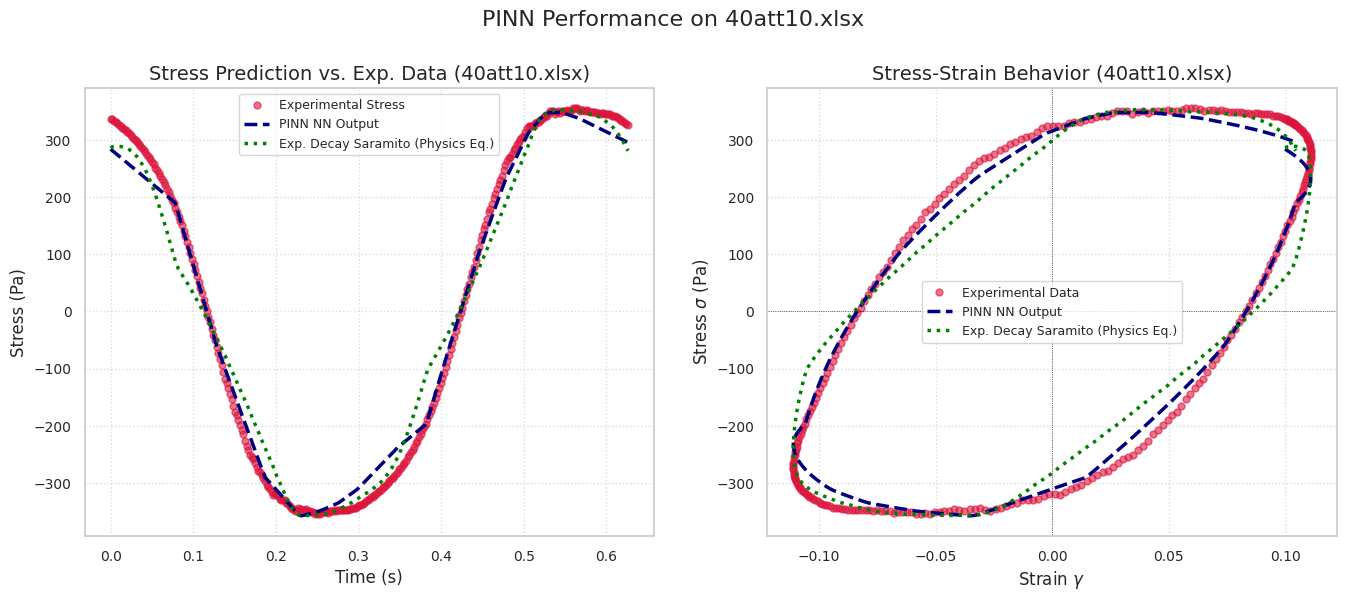

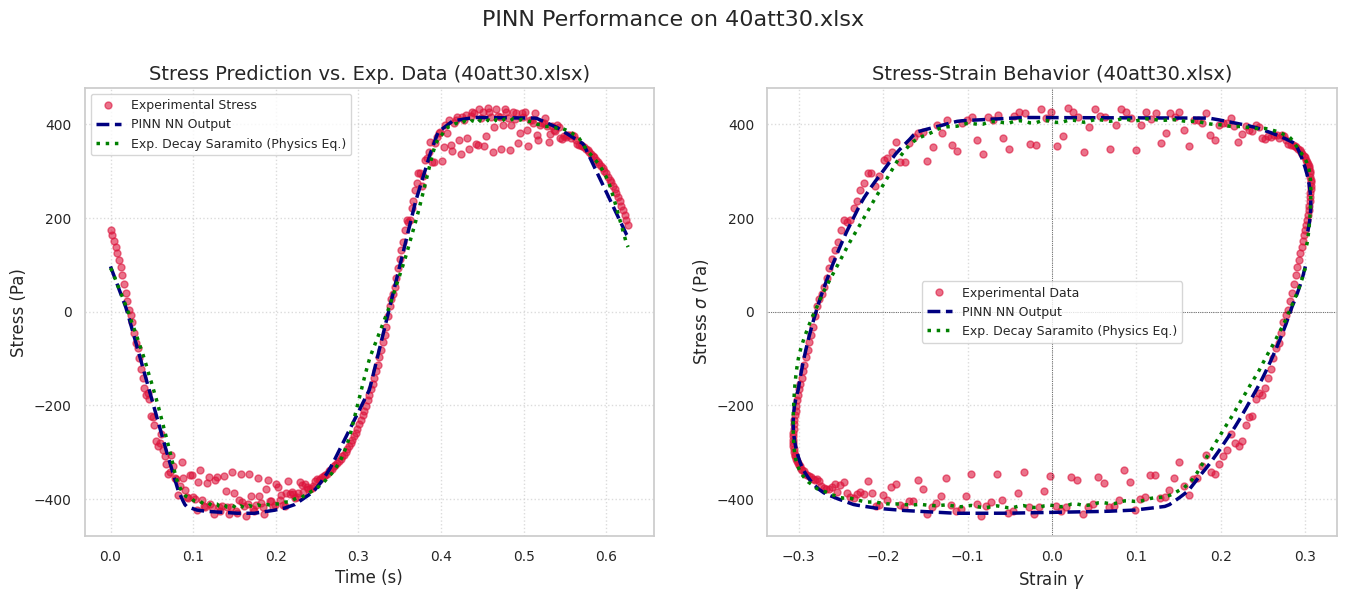

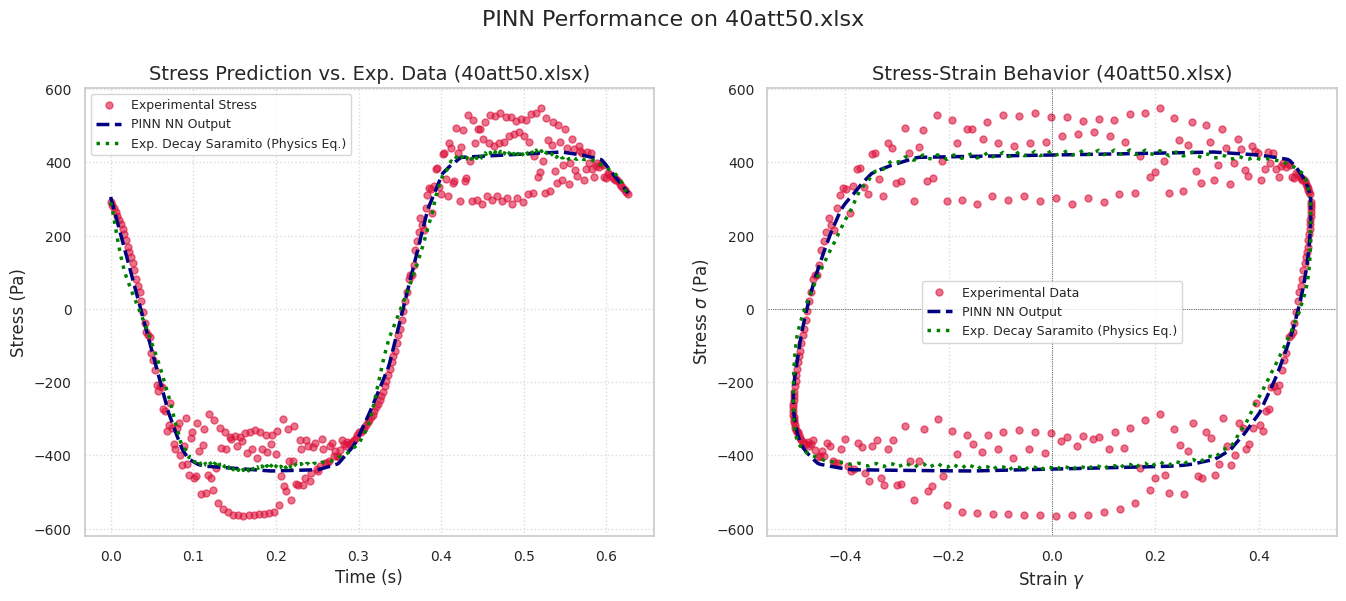

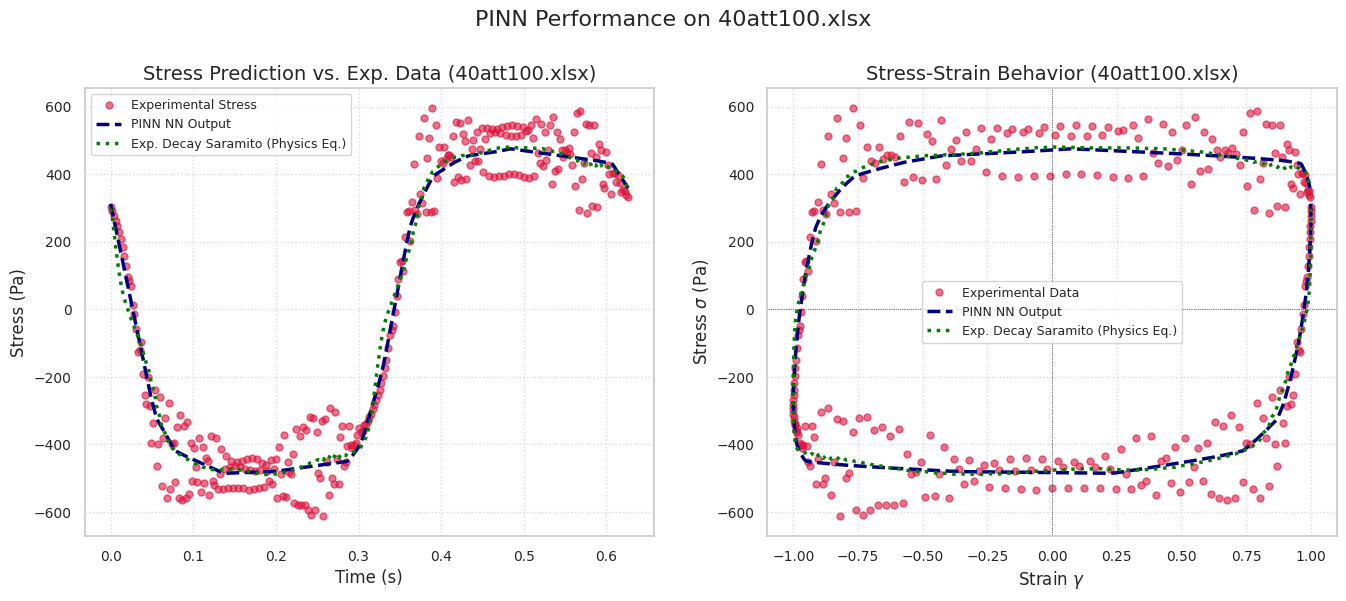

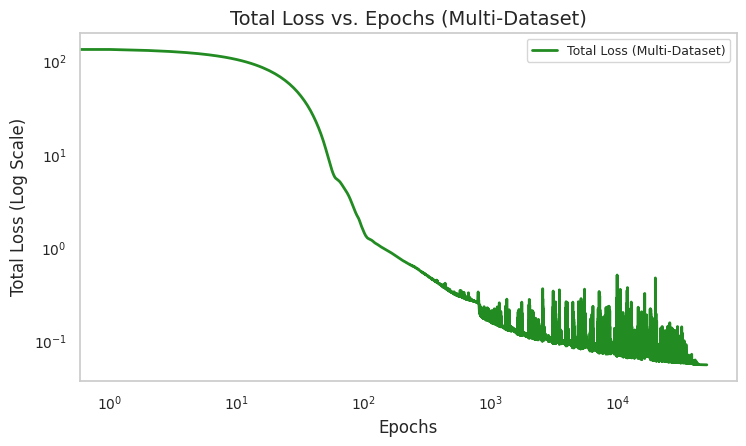

In [13]:
print("\nDisplaying final results plots...")
for i, file_path in enumerate(datasets_to_train):
    data = datasets_to_train[file_path]
    t_phys = data['t_phys']
    strain_exp_phys = data['strain_phys']
    stress_exp_phys = data['stress_phys']
    t_s = data['t_s']
    gamma_s = data['gamma_s']
    gamma_dot_s = data['gamma_dot_s']
    sigma_s_true = data['sigma_s_true']
    abs_gamma_s_for_training = data['abs_gamma_s_for_training']
    abs_gamma_dot_s_for_training = data['abs_gamma_dot_s_for_training']
    dt_s_val = data['dt_s']

    with torch.no_grad():
        nn_total_stress_pred_s_final = nn_models[i](t_s)
        nn_total_stress_pred_phys_final = scaler_stress_s2.inverse_transform(nn_total_stress_pred_s_final.cpu().numpy())
        _, _, _, physics_reconstructed_stress_s_final = loss_function_exp_decay_plateau(
            nn_total_stress_pred_s_final, sigma_s_true,
            G0_rec, Ginf_rec, γc_rec,
            η0_rec, ηinf_rec, γdotc_rec,
            ηp_rec, τ0_rec,
            abs_gamma_s_for_training, abs_gamma_dot_s_for_training,
            gamma_dot_s, dt_s_val
        )
        physics_reconstructed_stress_phys_final = scaler_stress_s2.inverse_transform(physics_reconstructed_stress_s_final.detach().cpu().numpy())

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Time vs Stress Plot
    axes[0].plot(t_phys, stress_exp_phys, 'o', color='crimson', markersize=5, label='Experimental Stress', alpha=0.6)
    axes[0].plot(t_phys, nn_total_stress_pred_phys_final, linestyle='--', color='navy', linewidth=2.5, label='PINN NN Output')
    axes[0].plot(t_phys, physics_reconstructed_stress_phys_final, linestyle=':', color='green', linewidth=2.5, label='Exp. Decay Saramito (Physics Eq.)')
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Stress (Pa)'); axes[0].set_title(f'Stress Prediction vs. Exp. Data ({os.path.basename(file_path)})', fontsize=14); axes[0].legend(frameon=True, loc='best'); axes[0].grid(True, linestyle=':', alpha=0.7)

    # Stress vs Strain Plot
    axes[1].plot(strain_exp_phys, stress_exp_phys, 'o', color='crimson', markersize=5, label='Experimental Data', alpha=0.6)
    axes[1].plot(strain_exp_phys, nn_total_stress_pred_phys_final, linestyle='--', color='navy', linewidth=2.5, label='PINN NN Output')
    axes[1].plot(strain_exp_phys, physics_reconstructed_stress_phys_final, linestyle=':', color='green', linewidth=2.5, label='Exp. Decay Saramito (Physics Eq.)')
    axes[1].set_xlabel(r'Strain $\gamma$'); axes[1].set_ylabel(r'Stress $\sigma$ (Pa)'); axes[1].set_title(f'Stress-Strain Behavior ({os.path.basename(file_path)})', fontsize=14); axes[1].legend(frameon=True, loc='best')
    axes[1].axhline(0, color='black', lw=0.5, linestyle=':'); axes[1].axvline(0, color='black', lw=0.5, linestyle=':')
    axes[1].grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout(pad=2.0)
    plt.suptitle(f'PINN Performance on {os.path.basename(file_path)}', fontsize=16, y=1.03)
    plt.show()

# Plot total loss
plt.figure(figsize=(8, 5))
epochs_ran = range(len(loss_values_exp_plateau))
if len(epochs_ran) > 0:
    plt.plot(epochs_ran, loss_values_exp_plateau, color='forestgreen', linewidth=2, label='Total Loss (Multi-Dataset)')
    if len(epochs_ran) > 1:
        try: plt.xscale('log'); plt.yscale('log')
        except ValueError: print("Warning: Could not set log scale for loss plot, using linear scale.")
    plt.xlabel('Epochs'); plt.ylabel('Total Loss (Log Scale)'); plt.title('Total Loss vs. Epochs (Multi-Dataset)', fontsize=14); plt.legend(frameon=True, loc='best'); plt.grid(True, which="both", ls="", alpha=0.7)
else:
    plt.text(0.5, 0.5, "No loss data to plot.", ha='center', va='center', transform=plt.gca().transAxes); plt.title('Total Loss vs. Epochs (No Data)', fontsize=14)
plt.tight_layout(pad=2.0); plt.show()

Paramter evloution plots


Displaying exponential decay parameter evolution plots...


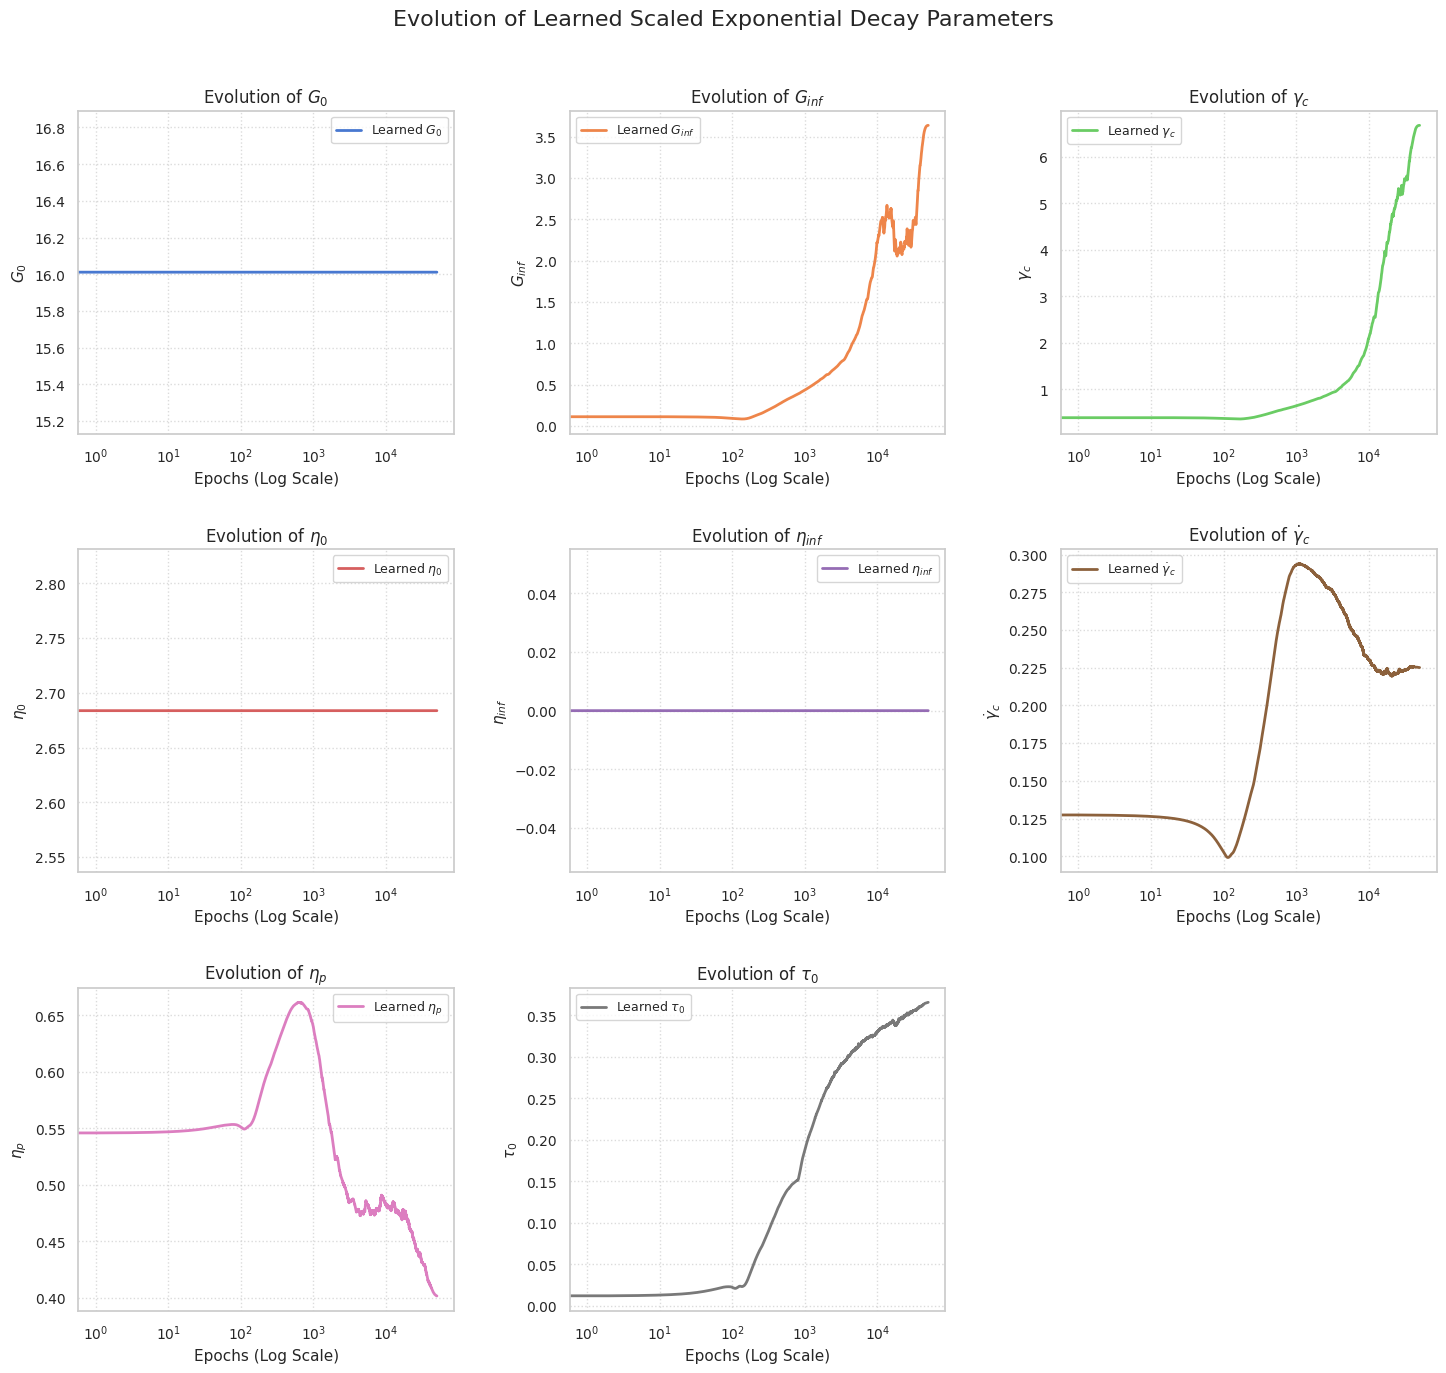

In [14]:
if len(param_history_exp_plateau) > 0:
    print("\nDisplaying exponential decay parameter evolution plots...")
    param_history_np = np.array(param_history_exp_plateau)
    epochs_array = np.arange(param_history_np.shape[0])

    param_labels_exp_plateau = [
        r'$G_0$', r'$G_{inf}$', r'$\gamma_c$',
        r'$\eta_0$', r'$\eta_{inf}$', r'$\dot{\gamma}_c$',
        r'$\eta_p$', r'$\tau_0$'
    ]

    num_params_to_plot = param_history_np.shape[1] - 1
    n_cols_params = 3
    n_rows_params = math.ceil(num_params_to_plot / n_cols_params)

    fig_params_exp, axes_params_exp = plt.subplots(
        n_rows_params, n_cols_params,
        figsize=(n_cols_params * 5, n_rows_params * 4.5)
    )

    if num_params_to_plot == 1:
        axes_params_exp = [axes_params_exp]

    axes_params_exp = axes_params_exp.flatten()

    for i in range(num_params_to_plot):
        ax = axes_params_exp[i]

        ax.plot(
            epochs_array,
            param_history_np[:, i],
            label=f'Learned {param_labels_exp_plateau[i]}',
            color=sns.color_palette("muted")[i % len(sns.color_palette("muted"))],
            linewidth=2
        )

        ax.set_xlabel('Epochs', fontsize=11)
        ax.set_ylabel(param_labels_exp_plateau[i], fontsize=11)
        ax.set_title(f'Evolution of {param_labels_exp_plateau[i]}', fontsize=12)

        ax.legend(frameon=True, loc='best')
        ax.grid(True, linestyle=':', alpha=0.7)

        if len(epochs_array) > 1000 and len(epochs_array) > 1:
            ax.set_xscale('log')
            ax.set_xlabel('Epochs (Log Scale)', fontsize=11)

    for j in range(i + 1, n_rows_params * n_cols_params):
        if j < len(axes_params_exp):
            fig_params_exp.delaxes(axes_params_exp[j])

    plt.tight_layout(pad=2.0)
    plt.suptitle('Evolution of Learned Scaled Exponential Decay Parameters', fontsize=16, y=1.03)
    plt.show()

else:
    print("\nSkipping exponential decay parameter evolution plots as no history was recorded.")

Pipkin diagram


Generating Pipkin-like diagram (Grids OFF, Targeted Legend)...


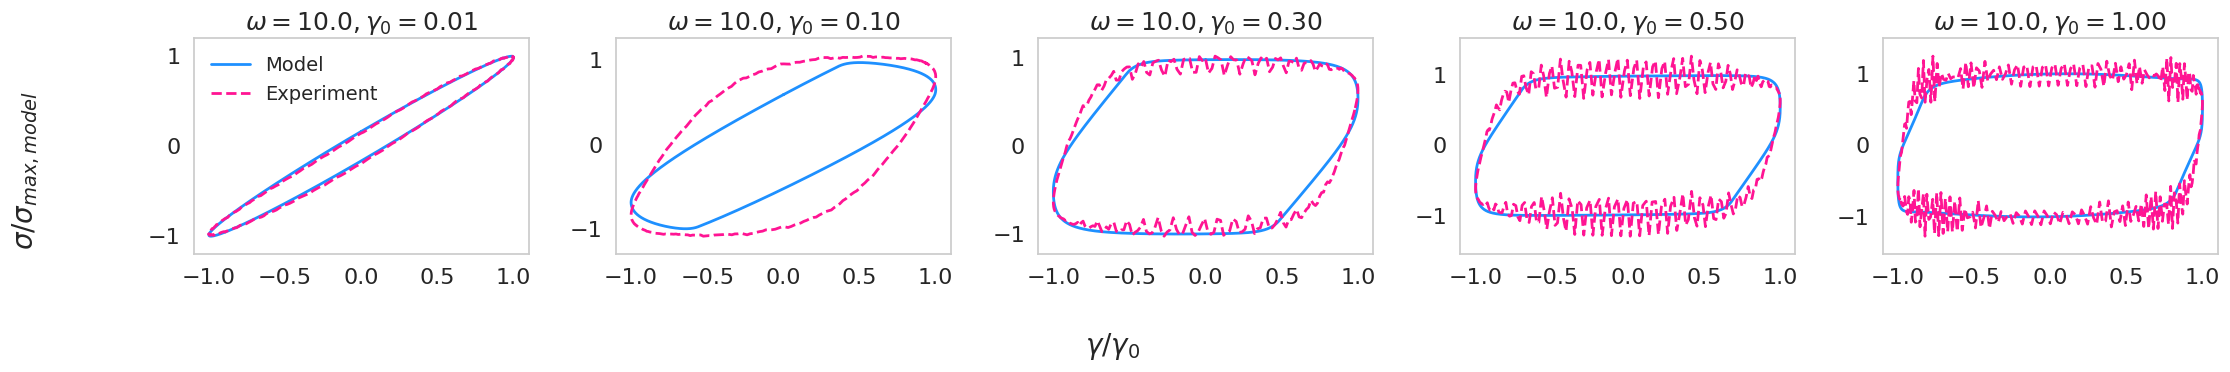

In [15]:
def solve_exp_decay_plateau_saramito_rk4_scaled(
    target_gamma_0_amplitude, omega_rad_s,
    num_cycles_sim, points_per_cycle,
    exp_decay_plateau_params_torch,
    initial_tau_vp_s_for_multicycle_sim,
    strain_scaler, strain_rate_scaler, stress_scaler, time_scaler
    ):

    G0, Ginf, γc, \
    η0, ηinf, γdotc, \
    ηp, τ0 = exp_decay_plateau_params_torch

    t_full_unscaled = np.linspace(0, num_cycles_sim * (2 * np.pi / omega_rad_s), num_cycles_sim * points_per_cycle, endpoint=False)
    strain_full_unscaled_np = strain_kinematics(t_full_unscaled, target_gamma_0_amplitude, omega_rad_s)
    strain_rate_full_unscaled_np = strain_rate_kinematics(t_full_unscaled, target_gamma_0_amplitude, omega_rad_s)

    strain_full_s_np = strain_scaler.transform(strain_full_unscaled_np.reshape(-1, 1)).flatten()
    strain_rate_full_s_np = strain_rate_scaler.transform(strain_rate_full_unscaled_np.reshape(-1, 1)).flatten()
    strain_full_s = torch.tensor(strain_full_s_np, dtype=torch.float32)
    strain_rate_full_s = torch.tensor(strain_rate_full_s_np, dtype=torch.float32)

    t_full_scaled_sim_np = time_scaler.transform(t_full_unscaled.reshape(-1,1)).flatten()
    dt_s_sim_val = (t_full_scaled_sim_np[1] - t_full_scaled_sim_np[0]) if len(t_full_scaled_sim_np) > 1 else 1.0
    dt_s_sim = torch.tensor(dt_s_sim_val, dtype=torch.float32)

    num_total_points_sim = len(strain_full_s)
    if num_total_points_sim == 0: return np.array([]), np.array([])

    tau_vp_s_sim_rk4 = torch.zeros(num_total_points_sim, dtype=torch.float32)
    if num_total_points_sim > 0: tau_vp_s_sim_rk4[0] = initial_tau_vp_s_for_multicycle_sim

    for i in range(num_total_points_sim - 1):
        tau_i,gamma_s_i,gamma_dot_s_i = tau_vp_s_sim_rk4[i],strain_full_s[i],strain_rate_full_s[i]
        gamma_s_mid,gamma_dot_s_mid = (strain_full_s[i]+strain_full_s[i+1])/2,(strain_rate_full_s[i]+strain_rate_full_s[i+1])/2
        gamma_s_i1,gamma_dot_s_i1 = strain_full_s[i+1],strain_rate_full_s[i+1]

        k1 = saramito_exp_decay_plateau_ode_rhs_scaled(tau_i, gamma_s_i, gamma_dot_s_i, G0, Ginf, γc, η0, ηinf, γdotc, ηp, τ0)
        k2 = saramito_exp_decay_plateau_ode_rhs_scaled(tau_i+dt_s_sim*k1/2.0, gamma_s_mid, gamma_dot_s_mid, G0, Ginf, γc, η0, ηinf, γdotc, ηp, τ0)
        k3 = saramito_exp_decay_plateau_ode_rhs_scaled(tau_i+dt_s_sim*k2/2.0, gamma_s_mid, gamma_dot_s_mid, G0, Ginf, γc, η0, ηinf, γdotc, ηp, τ0)
        k4 = saramito_exp_decay_plateau_ode_rhs_scaled(tau_i+dt_s_sim*k3, gamma_s_i1, gamma_dot_s_i1, G0, Ginf, γc, η0, ηinf, γdotc, ηp, τ0)

        tau_vp_s_sim_rk4[i+1] = tau_i + (dt_s_sim/6.0) * (k1 + 2*k2 + 2*k3 + k4)

    abs_gamma_dot_s_sim = torch.abs(strain_rate_full_s)
    eff_eta_sim = ηinf + (η0 - ηinf) * torch.exp(-abs_gamma_dot_s_sim / (γdotc + EPS))
    total_stress_s_sim = tau_vp_s_sim_rk4 + eff_eta_sim * strain_rate_full_s

    start_idx_last_cycle = (num_cycles_sim - 1) * points_per_cycle
    if start_idx_last_cycle < 0 : start_idx_last_cycle = 0

    strain_unnorm_last_cycle = strain_full_unscaled_np[start_idx_last_cycle:]
    stress_s_last_cycle = total_stress_s_sim[start_idx_last_cycle:]
    stress_unnorm_last_cycle = stress_scaler.inverse_transform(stress_s_last_cycle.detach().cpu().numpy().reshape(-1,1)).flatten()

    # --- CENTER STRESS (Fix Asymmetry) ---
    if len(stress_unnorm_last_cycle) > 0:
        stress_unnorm_last_cycle = stress_unnorm_last_cycle - np.mean(stress_unnorm_last_cycle)

    return strain_unnorm_last_cycle, stress_unnorm_last_cycle

if 'G0_rec' in locals() :
    print("\nGenerating Pipkin-like diagram (Grids OFF, Targeted Legend)...")
    pipkin_amplitudes = [0.01, 0.1, 0.3, 0.5, 1.0]
    pipkin_frequencies = [10.0]

    experimental_files_map = {
        0.01: '40att1.xlsx', 0.1:  '40att10.xlsx',
        0.3:  '40att30.xlsx', 0.5:  '40att50.xlsx',
        1.0:  '40att100.xlsx'
    }
    experimental_data_frequency_for_map = 10.0

    points_per_cycle_pipkin = 4000
    num_cycles_for_steady_state_pipkin = 10

    n_freqs = len(pipkin_frequencies)
    n_amps = len(pipkin_amplitudes)

    fig_pipkin, axes_pipkin = plt.subplots(n_freqs, n_amps,
                                           figsize=(n_amps * 4.5, n_freqs * 4.0),
                                           sharex=True, sharey=False)

    if n_freqs == 1 and n_amps == 1: axes_pipkin = np.array([[axes_pipkin]])
    elif n_freqs == 1: axes_pipkin = np.array([axes_pipkin])
    elif n_amps == 1: axes_pipkin = np.array([[ax] for ax in axes_pipkin])

    # --- COLORS & FONTS ---
    model_plot_color = 'dodgerblue'
    exp_plot_color   = (1.0, 0.078, 0.576) # Hot Pink
    font_title  = 18
    font_label  = 20
    font_tick   = 16
    font_legend = 14
    font_supt   = 24

    final_exp_decay_plateau_params_values = (
        G0_rec, Ginf_rec, γc_rec,
        η0_rec, ηinf_rec, γdotc_rec,
        ηp_rec, τ0_rec
    )
    final_exp_decay_plateau_params_torch = tuple(p if isinstance(p, torch.Tensor) else torch.tensor(p.item() if hasattr(p, 'item') else p, dtype=torch.float32) for p in final_exp_decay_plateau_params_values)


    for row_idx, current_omega_pipkin in enumerate(pipkin_frequencies):
        for col_idx, current_gamma_0_target_pipkin in enumerate(pipkin_amplitudes):
            ax = axes_pipkin[row_idx, col_idx]

            # --- Explicitly Force Grid OFF ---
            ax.grid(False)

            if current_gamma_0_target_pipkin <= 0.01 and G0_physical_from_stage1 is not None:
                # Kelvin-Voigt for low strain
                t_kv = np.linspace(0, (2 * np.pi / current_omega_pipkin), points_per_cycle_pipkin, endpoint=False)
                strain_kv = strain_kinematics(t_kv, current_gamma_0_target_pipkin, current_omega_pipkin)
                strain_rate_kv = strain_rate_kinematics(t_kv, current_gamma_0_target_pipkin, current_omega_pipkin)
                model_strain_unnorm_cycle = strain_kv
                model_stress_unnorm_cycle = G0_physical_from_stage1 * strain_kv + eta0_solvent_physical_from_stage1 * strain_rate_kv
            else:
                model_strain_unnorm_cycle, model_stress_unnorm_cycle = solve_exp_decay_plateau_saramito_rk4_scaled(
                    target_gamma_0_amplitude = current_gamma_0_target_pipkin,
                    omega_rad_s = current_omega_pipkin,
                    num_cycles_sim = num_cycles_for_steady_state_pipkin,
                    points_per_cycle = points_per_cycle_pipkin,
                    exp_decay_plateau_params_torch = final_exp_decay_plateau_params_torch,
                    initial_tau_vp_s_for_multicycle_sim = 0.0,
                    strain_scaler=scaler_strain_s2,
                    strain_rate_scaler=scaler_strain_rate_s2,
                    stress_scaler=scaler_stress_s2,
                    time_scaler=scaler_t_s2
                )

            if model_strain_unnorm_cycle.size == 0 or model_stress_unnorm_cycle.size == 0:
                ax.text(0.5, 0.5, "Sim Failed", ha='center', va='center', transform=ax.transAxes, fontsize=12, color='red')
                ax.set_title(rf'$\omega={current_omega_pipkin:.1f}, \gamma_0={current_gamma_0_target_pipkin:.2f}$', fontsize=font_title)
                continue

            if not np.all(np.isfinite(model_stress_unnorm_cycle)):
                model_stress_unnorm_cycle = np.nan_to_num(model_stress_unnorm_cycle, nan=0.0, posinf=np.finfo(np.float64).max/2, neginf=np.finfo(np.float64).min/2)

            # --- NORMALIZATION ---
            max_abs_model_stress = np.max(np.abs(model_stress_unnorm_cycle))
            if max_abs_model_stress < EPS: max_abs_model_stress = 1.0

            if current_gamma_0_target_pipkin < EPS : norm_model_strain_to_plot = np.zeros_like(model_strain_unnorm_cycle)
            else: norm_model_strain_to_plot = model_strain_unnorm_cycle / current_gamma_0_target_pipkin

            norm_model_stress_to_plot = model_stress_unnorm_cycle / max_abs_model_stress

            ax.plot(norm_model_strain_to_plot, norm_model_stress_to_plot, color=model_plot_color, linewidth=2, label='Model')
            current_plot_y_values = [norm_model_stress_to_plot]

            # --- LOAD EXPERIMENT ---
            have_exp = False
            if abs(current_omega_pipkin - experimental_data_frequency_for_map) < 1e-6:
                if current_gamma_0_target_pipkin in experimental_files_map:
                    exp_file_path = experimental_files_map[current_gamma_0_target_pipkin]
                    try:
                        exp_df_pipkin = pd.read_excel(exp_file_path)
                        exp_strain_pipkin_data = exp_df_pipkin[STRAIN_COLUMN_NAME].values
                        exp_stress_pipkin_data = exp_df_pipkin[STRESS_COLUMN_NAME].values

                        if not np.all(np.isfinite(exp_stress_pipkin_data)):
                            exp_stress_pipkin_data = np.nan_to_num(exp_stress_pipkin_data)

                        exp_stress_pipkin_data = exp_stress_pipkin_data - np.mean(exp_stress_pipkin_data)

                        actual_exp_gamma_0_pipkin = np.max(np.abs(exp_strain_pipkin_data))
                        if actual_exp_gamma_0_pipkin < EPS: norm_exp_strain_to_plot = np.zeros_like(exp_strain_pipkin_data)
                        else: norm_exp_strain_to_plot = exp_strain_pipkin_data / actual_exp_gamma_0_pipkin

                        norm_exp_stress_to_plot = exp_stress_pipkin_data / max_abs_model_stress

                        ax.plot(norm_exp_strain_to_plot, norm_exp_stress_to_plot, color=exp_plot_color, linestyle='--', linewidth=2, label='Experiment')

                        # --- TARGETED LEGEND: Omega=10, Gamma=0.01 ONLY ---
                        if (abs(current_omega_pipkin - 10.0) < 1e-6 and abs(current_gamma_0_target_pipkin - 0.01) < 1e-6):
                             ax.legend(fontsize=font_legend, frameon=False)

                        current_plot_y_values.append(norm_exp_stress_to_plot)
                        have_exp = True
                    except FileNotFoundError: print(f"    WARNING: File not found: {exp_file_path}")
                    except KeyError as e_key: print(f"    WARNING: Column {e_key} not found in {exp_file_path}")

            ax.set_title(rf'$\omega={current_omega_pipkin:.1f}, \gamma_0={current_gamma_0_target_pipkin:.2f}$', fontsize=font_title)

            # --- NO ZERO LINES, NO GRID ---
            ax.set_xlim([-1.1, 1.1])
            ax.tick_params(axis='both', which='major', labelsize=font_tick)

            # Dynamic Y-Limits
            all_finite_y_for_subplot = np.concatenate([arr[np.isfinite(arr)] for arr in current_plot_y_values if arr.size > 0])
            if all_finite_y_for_subplot.size == 0: min_y_lim, max_y_lim = -1.1, 1.1
            else:
                min_y_val,max_y_val = np.min(all_finite_y_for_subplot),np.max(all_finite_y_for_subplot)
                plot_range_y = max_y_val - min_y_val
                if plot_range_y < EPS:
                    y_padding = 0.1
                    min_y_lim = min_y_val - y_padding
                    max_y_lim = max_y_val + y_padding
                else:
                    y_padding = 0.1 * plot_range_y
                    min_y_lim,max_y_lim = min_y_val - y_padding,max_y_val + y_padding
            ax.set_ylim([min_y_lim, max_y_lim])

    fig_pipkin.supxlabel(r'$\gamma/\gamma_0$', fontsize=font_label, y=0.02)
    fig_pipkin.supylabel(r'$\sigma/\sigma_{max,model}$', fontsize=font_label, x=0.01)
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.95]); plt.show()
else:
    print("\nSkipping Pipkin-like diagram: Parameters not recovered yet.")